### Phase 3 - Data Preparation

In this phase, there are an integrated, cleaned, and formatted dataset will be implemented. The new filtered dataset will be released for the future stages. This is what happens in phase 3:

* Load dataset 

* Drop duplicate rows 

* Optimize columns (clean measurements unit and residual texts, create new features 
such as combined_fuel_economy, legroom and size_of_vehicle) 

* Handle and fill missing values with popular value in the column 

* Convert to new dataset 

* Visualize the data with outliers  

* Load new dataset as phase 2 and encoding label  

* Select class and target will be implemented in phase 4 for more accuracy

### Import Libraries & Load Dataset

In [1]:
import polars as pl

file_path = "/kaggle/input/us-used-cars-dataset/used_cars_data.csv"

df = pl.read_csv(file_path, ignore_errors=True)

print(df.shape)
print(df.columns)
print(df.describe())
print("First 5 rows:")
print(df.head())


(3000040, 66)
['vin', 'back_legroom', 'bed', 'bed_height', 'bed_length', 'body_type', 'cabin', 'city', 'city_fuel_economy', 'combine_fuel_economy', 'daysonmarket', 'dealer_zip', 'description', 'engine_cylinders', 'engine_displacement', 'engine_type', 'exterior_color', 'fleet', 'frame_damaged', 'franchise_dealer', 'franchise_make', 'front_legroom', 'fuel_tank_volume', 'fuel_type', 'has_accidents', 'height', 'highway_fuel_economy', 'horsepower', 'interior_color', 'isCab', 'is_certified', 'is_cpo', 'is_new', 'is_oemcpo', 'latitude', 'length', 'listed_date', 'listing_color', 'listing_id', 'longitude', 'main_picture_url', 'major_options', 'make_name', 'maximum_seating', 'mileage', 'model_name', 'owner_count', 'power', 'price', 'salvage', 'savings_amount', 'seller_rating', 'sp_id', 'sp_name', 'theft_title', 'torque', 'transmission', 'transmission_display', 'trimId', 'trim_name', 'vehicle_damage_category', 'wheel_system', 'wheel_system_display', 'wheelbase', 'width', 'year']
shape: (9, 67)
┌─

### Drop Duplicates

In [2]:
df = df.unique()

df.height

3000000

### Clean measurement columns (units -> numeric floats)
Many columns store values like "40 in" or "18 gal" as strings.
 
 Here we:
  - Remove unit strings (in, gal, etc.)
  - Remove any non-numeric characters
  - Treat "--" or empty strings as missing
  - Cast the result to Float64

In [3]:
def clean_measurement_expr(col_name: str):
    col_utf8 = pl.col(col_name).cast(pl.Utf8)       

    return (
        pl.when(
            col_utf8.is_null() | (col_utf8 == "--")
        )
        .then(None)
        .otherwise(
            col_utf8
            .str.replace_all(r"(in|gal)", "")       # remove units
            .str.replace_all(r"[^0-9.\-]", "")      # keep only valid numeric characters
            .str.strip_chars()                      # remove leading/trailing spaces
            .map_elements(
                lambda x: x if x != "" else None,
                return_dtype=pl.Utf8               
            )
        )
        .cast(pl.Float64, strict=False)
        .alias(col_name)
    )

columns_to_clean = [
    "back_legroom", "front_legroom", "fuel_tank_volume",
    "height", "length", "wheelbase", "width",
]

existing_cols_to_clean = [c for c in columns_to_clean if c in df.columns]

df = df.with_columns([clean_measurement_expr(col) for col in existing_cols_to_clean])


###  Combined fuel economy feature

Here we:
 - Handle missing city/highway fuel economy
 - Create 'combined_fuel_economy' as their average
 - Drop original detailed fuel economy columns
 - Also drop the original Kaggle 'combine_fuel_economy' to avoid duplicates


In [4]:
# Compute medians as scalars
hwy_med = df["highway_fuel_economy"].median()
city_med = df["city_fuel_economy"].median()

# Fill missing values with median
df = df.with_columns([
    pl.col("highway_fuel_economy").fill_null(hwy_med),
    pl.col("city_fuel_economy").fill_null(city_med),
])

# New feature: combined fuel economy (simple average)
df = df.with_columns(
    ((pl.col("city_fuel_economy") + pl.col("highway_fuel_economy")) / 2)
    .alias("combined_fuel_economy")
)

# Drop original detailed columns + original combine_fuel_economy from Kaggle
df = df.drop(["city_fuel_economy", "highway_fuel_economy", "combine_fuel_economy"])

print("Created 'combined_fuel_economy' and dropped city/highway/combine_fuel_economy.")


Created 'combined_fuel_economy' and dropped city/highway/combine_fuel_economy.


### Accident / incident flag

Here we:
 - Clean 'has_accidents'
 - Rename to 'has_incidents'
 - Convert to boolean True/False for modelling

In [5]:
# Fill nulls with "False"
df = df.with_columns(
    pl.col("has_accidents").fill_null("False")
)

# Rename column
df = df.rename({"has_accidents": "has_incidents"})

# Convert "True"/"False" -> Boolean
df = df.with_columns(
    (pl.col("has_incidents") == "True")
    .cast(pl.Boolean)
    .alias("has_incidents")
)

print("Cleaned 'has_incidents' as Boolean.")

Cleaned 'has_incidents' as Boolean.


### Legroom feature (front + back)

Here we:

- Fill missing front/back legroom with mean
- Create a combined 'legroom' feature
- Drop original legroom columns


In [6]:
front_mean = df["front_legroom"].mean()
back_mean  = df["back_legroom"].mean()

# Fill nulls with column means
df = df.with_columns([
    pl.col("front_legroom").fill_null(front_mean),
    pl.col("back_legroom").fill_null(back_mean),
])

# Combined legroom
df = df.with_columns(
    (pl.col("front_legroom") + pl.col("back_legroom")).alias("legroom")
)

# Drop original columns
df = df.drop(["front_legroom", "back_legroom"])

print("Created 'legroom' and dropped front/back legroom columns.")


Created 'legroom' and dropped front/back legroom columns.


### Size of vehicle feature

Here we:

* Fill missing size-related values using the median
* Create a combined `size_of_vehicle` feature by summing them
* Drop the original size component columns


In [7]:
cols_to_fill = ["wheelbase", "length", "width", "height", "fuel_tank_volume"]

# Fill missing with median for each column
for col in cols_to_fill:
    median_val = df[col].median()
    df = df.with_columns(
        pl.col(col).fill_null(median_val)
    )

# Create size_of_vehicle as sum of the components
df = df.with_columns(
    (
        pl.col("length") +
        pl.col("width") +
        pl.col("height") +
        pl.col("wheelbase") +
        pl.col("fuel_tank_volume")
    ).alias("size_of_vehicle")
)

# Drop original columns
df = df.drop(cols_to_fill)

print("Created 'size_of_vehicle' and dropped size component columns.")


Created 'size_of_vehicle' and dropped size component columns.


### Torque cleaning feature

Here we:

* Ensure `torque` is numeric
* Extract the numeric value from strings like `"277 lb-ft @ 1600 rpm"`
* Fill missing `torque` values with the mean


In [8]:
# Ensure string
df = df.with_columns(
    pl.col("torque").cast(pl.Utf8)
)

# Replace invalid tokens with null
invalid_values = ["--", "", "null"]
df = df.with_columns(
    pl.when(pl.col("torque").is_in(invalid_values))
      .then(None)
      .otherwise(pl.col("torque"))
      .alias("torque")
)

# Extract first numeric part and cast to float
df = df.with_columns(
    pl.col("torque")
      .str.extract(r"(\d+\.?\d*)")
      .cast(pl.Float64)
      .alias("torque")
)

# Fill nulls with mean
torque_mean = df["torque"].mean()
df = df.with_columns(
    pl.col("torque").fill_null(torque_mean)
)

print("Cleaned 'torque' column as numeric.")


Cleaned 'torque' column as numeric.


### Mileage cleaning feature

Here we:

* Fill missing `mileage` values with the mean


In [9]:
mileage_mean = df["mileage"].mean()
df = df.with_columns(
    pl.col("mileage").fill_null(mileage_mean)
)

print("Filled missing 'mileage' with mean:", mileage_mean)


Filled missing 'mileage' with mean: 31146.901467040527


### Mileage distribution (after cleaning, before outlier removal)

Here we:

* Visualize the distribution of `mileage` right after filling missing values
* Show the “raw” cleaned data before removing extreme outliers with IQR


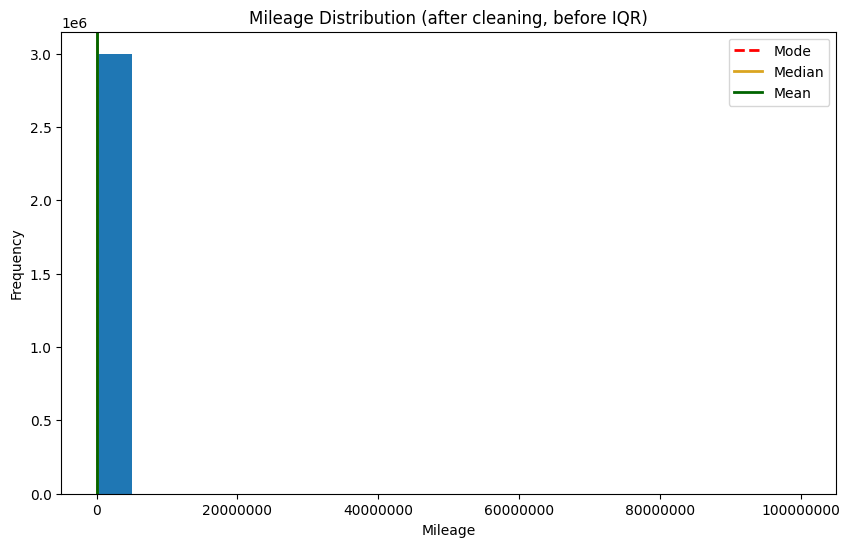

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Convert mileage column to a NumPy array for plotting
mileage = df["mileage"].to_numpy()

plt.figure(figsize=(10, 6))
plt.hist(mileage, bins=20)
plt.title("Mileage Distribution (after cleaning, before IQR)")
plt.xlabel("Mileage")
plt.ylabel("Frequency")

# Compute statistics from Polars
mode_val = df["mileage"].mode()[0]
median_val = df["mileage"].median()
mean_val = df["mileage"].mean()

# Add vertical lines for mode, median, and mean
plt.axvline(mode_val, color="r", linestyle="dashed", linewidth=2, label="Mode")
plt.axvline(median_val, color="goldenrod", linewidth=2, label="Median")
plt.axvline(mean_val, color="darkgreen", linewidth=2, label="Mean")

# Remove scientific notation from x-axis
plt.ticklabel_format(style="plain", axis="x")

plt.legend()
plt.show()


The graph shows us that there are a large amount of outliers in the column. So we will need to remove the outliers before we can fill in the null values with the mean or median value. We will use the interquartile range to remove the outliers.

### Transmission feature

Here we:

* Fill missing `transmission` values with the most common category (mode)


In [11]:
# Compute mode (most frequent non-null value)
trans_mode_vals = df["transmission"].drop_nulls().mode().to_list()
trans_mode_val = trans_mode_vals[0] if trans_mode_vals else "A"  # fallback

# Fill nulls with the mode
df = df.with_columns(
    pl.col("transmission").fill_null(trans_mode_val)
)

print(f"Filled missing 'transmission' values with mode: {trans_mode_val}")


Filled missing 'transmission' values with mode: A


### Maximum seating feature

Here we:

* Clean `maximum_seating` values (e.g., `"5 seats"`, `"--"`)
* Replace missing values with the most frequent value
* Convert to integer (e.g., `5`)


In [12]:
# Step 1: Treat "--" as null
df = df.with_columns(
    pl.when(pl.col("maximum_seating") == "--")
      .then(None)
      .otherwise(pl.col("maximum_seating"))
      .alias("maximum_seating")
)

# Step 2: Compute mode (most common non-null value)
seats_mode_vals = df["maximum_seating"].drop_nulls().mode().to_list()
seats_mode_val = seats_mode_vals[0] if seats_mode_vals else "5 seats"  # fallback

# Step 3: Fill nulls with the mode
df = df.with_columns(
    pl.col("maximum_seating").fill_null(seats_mode_val)
)

# Step 4: Remove " seats" and cast to integer
df = df.with_columns(
    pl.col("maximum_seating")
      .str.replace(" seats", "")
      .cast(pl.Int64, strict=False)
      .alias("maximum_seating")
)

print(f"Cleaned 'maximum_seating' and converted to integer. Mode used: {seats_mode_val}")


Cleaned 'maximum_seating' and converted to integer. Mode used: 5 seats


### Fuel type normalization feature

Here we:

* Normalize textual fuel descriptions into clean categories
  (e.g., `"turbo diesel"`, `"tdi"` → `"Diesel"`, `"EV"` → `"Electric"`)
* Default to `"Gasoline"` when no match is found


In [13]:
import re

def find_fuel_type_keyword(text):
    desc = "" if text is None else str(text).lower().strip()

    if desc == "" or desc == "nan":
        return None

    fuel_rules = [
        (r'\b(diesel|turbo\s*diesel|duramax|tdi)\b', 'Diesel'),
        (r'\bbiodiesel\b', 'Biodiesel'),
        (r'\b(flex\s*fuel|ffv|e85)\b', 'Flex Fuel Vehicle'),
        (r'\b(hybrid|phev)\b', 'Hybrid'),
        (r'\b(electric\s*vehicle|ev|battery\s*electric|all\s*electric)\b', 'Electric'),
        (r'\b(cng|compressed\s*natural\s*gas)\b', 'Compressed Natural Gas'),
        (r'\bpropane\b', 'Propane'),
        (r'\b(gasoline|petrol|gas|gdi)\b', 'Gasoline'),
        (r'\d\.\d[lL]\s*(v6|v8|24v|vvti?|gdi)(?!\s*(diesel|hybrid|electric))', 'Gasoline'),
    ]

    for pattern, fuel_type in fuel_rules:
        if re.search(pattern, desc):
            return fuel_type

    return None  # no match

# Ensure column is string
df = df.with_columns(
    pl.col("fuel_type").cast(pl.Utf8)
)

# Apply function and default to gasoline
df = df.with_columns(
    pl.col("fuel_type")
      .map_elements(find_fuel_type_keyword, return_dtype=pl.Utf8)
      .fill_null("Gasoline")
      .alias("fuel_type")
)

print("Normalized 'fuel_type' values.")


Normalized 'fuel_type' values.


### Body type feature

Here we:

* Fill missing `body_type` values with the most common category (mode)


In [14]:
# Compute mode (most frequent non-null value)
body_mode_vals = df["body_type"].drop_nulls().mode().to_list()
body_mode_val = body_mode_vals[0] if body_mode_vals else "SUV / Crossover"  # fallback

# Fill nulls with the mode
df = df.with_columns(
    pl.col("body_type").fill_null(body_mode_val)
)

print(f"Filled missing 'body_type' with mode: {body_mode_val}")


Filled missing 'body_type' with mode: SUV / Crossover


### Horsepower cleaning feature

Here we:

* Extract numeric `horsepower` from strings
* Convert to float
* Fill missing values with the mode (most common value)


In [15]:
df = df.with_columns(
    pl.col("horsepower")
      .cast(pl.Utf8)                     # ensure string
      .str.replace_all(r"[^0-9.]", "")  # keep only digits and dot
      .str.strip_chars()
      .map_elements(
          lambda x: None if x == "" else x,
          return_dtype=pl.Utf8          
      )
      .cast(pl.Float64)                 # convert to float
      .alias("horsepower")
)

# Compute mode safely (if no mode exists, use None)
hp_mode = df["horsepower"].drop_nulls().mode().to_list()
hp_mode_value = hp_mode[0] if hp_mode else None

# Fill nulls (if None, it does nothing)
df = df.with_columns(
    pl.col("horsepower").fill_null(hp_mode_value)
)

print("Filled missing 'horsepower' with mode:", hp_mode_value)


Filled missing 'horsepower' with mode: 170.0


### Wheel system feature

Here we:

* Fill missing `wheel_system` values with the most common category (mode)


In [16]:
# Compute mode (most frequent non-null value)
wheel_mode_vals = df["wheel_system"].drop_nulls().mode().to_list()
wheel_mode_val = wheel_mode_vals[0] if wheel_mode_vals else "FWD"  # fallback

# Fill nulls with the mode
df = df.with_columns(
    pl.col("wheel_system").fill_null(wheel_mode_val)
)

print(f"Filled missing 'wheel_system' with mode: {wheel_mode_val}")


Filled missing 'wheel_system' with mode: FWD


### Engine type feature

Here we:

* Infer `engine_type` from `fuel_type` where missing
  (e.g., `fuel_type = "Diesel"` → `engine_type = "Diesel engine"`)


In [17]:
def fill_engine_type_based_on_fuel(df, engine_col="engine_type", fuel_col="fuel_type"):
    fuel_types = [
        "Gasoline",
        "Electric",
        "Diesel",
        "Hybrid",
        "Flex Fuel Vehicle",
        "Biodiesel",
        "Compressed Natural Gas",
        "Propane",
    ]

    for fuel in fuel_types:
        df = df.with_columns(
            pl.when(pl.col(engine_col).is_null() & (pl.col(fuel_col) == fuel))
              .then(pl.lit(f"{fuel} engine"))
              .otherwise(pl.col(engine_col))
              .alias(engine_col)
        )

    return df

df = fill_engine_type_based_on_fuel(df)
print("Filled missing 'engine_type' values based on 'fuel_type' where possible.")


Filled missing 'engine_type' values based on 'fuel_type' where possible.


### Extreme mileage outlier removal

Here we:

* Remove cars with extremely low or high `mileage` using the Interquartile Range (IQR) rule
* Prevent distortion of models by extreme values


In [18]:
mileage_series = df["mileage"]
q1 = mileage_series.quantile(0.25)
q3 = mileage_series.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df = df.filter(
    (pl.col("mileage") >= lower_bound) &
    (pl.col("mileage") <= upper_bound)
)

print("After mileage IQR outlier removal, rows:", df.height)


After mileage IQR outlier removal, rows: 2743730


### Major Options Count Feature 

Here we:
* Clean the major_options string structure
* Create a 'major_options_count' column (counting number of items)
* Fill missing counts with the mean
* Drop the original text column

In [19]:
# Null count & percentage
null_count = df["major_options"].null_count()
total_rows = df.height
null_percent = (null_count / total_rows) * 100
print(f"major_options: {null_count} nulls ({null_percent:.2f}%)")

# Value percentages 
value_counts = (
    df.group_by("major_options")
      .agg(pl.len().alias("count"))
      .with_columns((pl.col("count") / total_rows * 100).alias("percent"))
)
print(value_counts)

# Create major_options_count 
df = df.with_columns(
    pl.when(pl.col("major_options").is_null())
      .then(None)
      .otherwise(pl.col("major_options").cast(pl.Utf8))
      .alias("major_options")
)

df = df.with_columns(
    pl.col("major_options")
      .str.count_matches(",")
      .fill_null(-1)
      .alias("major_options_count_raw")
)

df = df.with_columns(
    pl.when(pl.col("major_options_count_raw") == -1)
      .then(None)
      .otherwise(pl.col("major_options_count_raw") + 1)
      .alias("major_options_count")
).drop("major_options_count_raw")


major_options: 170559 nulls (6.22%)
shape: (257_699, 3)
┌─────────────────────────────────┬───────┬──────────┐
│ major_options                   ┆ count ┆ percent  │
│ ---                             ┆ ---   ┆ ---      │
│ str                             ┆ u32   ┆ f64      │
╞═════════════════════════════════╪═══════╪══════════╡
│ ['Leather Seats', 'Sunroof/Moo… ┆ 20    ┆ 0.000729 │
│ ['Sunroof/Moonroof', 'Navigati… ┆ 1     ┆ 0.000036 │
│ ['101A Mid Equipment Group', '… ┆ 1     ┆ 0.000036 │
│ ['Leather Seats', 'Sunroof/Moo… ┆ 1     ┆ 0.000036 │
│ ['Sport Package', 'Leather Sea… ┆ 1     ┆ 0.000036 │
│ …                               ┆ …     ┆ …        │
│ ['Sunroof/Moonroof', 'Bluetoot… ┆ 1     ┆ 0.000036 │
│ ['301A Mid Equipment Group', '… ┆ 6     ┆ 0.000219 │
│ ['Power Package', 'Navigation … ┆ 1     ┆ 0.000036 │
│ ['Leather Seats', 'Power Packa… ┆ 1     ┆ 0.000036 │
│ ['Value Package', 'Alloy Wheel… ┆ 1     ┆ 0.000036 │
└─────────────────────────────────┴───────┴──────────┘


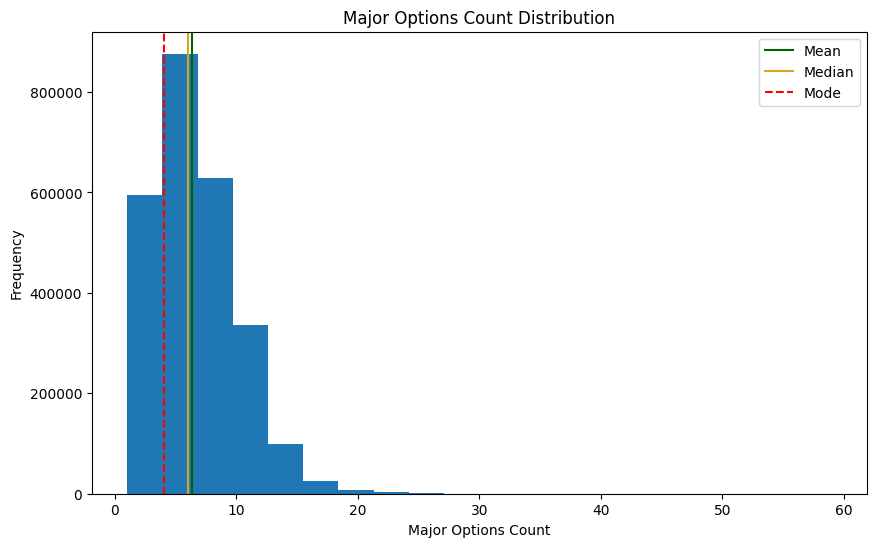

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Drop null values before plotting
hist_data = df["major_options_count"].drop_nulls().to_numpy()

plt.figure(figsize=(10,6))
plt.hist(hist_data, bins=20)
plt.title("Major Options Count Distribution")
plt.xlabel("Major Options Count")
plt.ylabel("Frequency")

# Mean / Median / Mode
plt.axvline(np.mean(hist_data), color="darkgreen", label="Mean")
plt.axvline(np.median(hist_data), color="goldenrod", label="Median")

mode_val = df["major_options_count"].drop_nulls().mode()[0]
plt.axvline(mode_val, color="red", linestyle="dashed", label="Mode")

plt.legend()
plt.show()


In [21]:
# Fill nulls with mean 
mean_val = df["major_options_count"].mean()
df = df.with_columns(
    pl.col("major_options_count").fill_null(mean_val)
)

print("Filled nulls in major_options_count with mean:", mean_val)

# Drop original unstructured text column
df = df.drop("major_options")


Filled nulls in major_options_count with mean: 6.346769802706466


### Feature selection for modelling (Phase 4)

Here we:

* Build `new_df` as the cleaned, integrated dataset for modelling
* Include:

  * `price` – main regression target
  * `daysonmarket` – sale-time target
  * Core technical features
  * Brand & model
  * Condition/incident flags
  * `major_options_count` – for analyzing which options add value


In [22]:
selected_columns = [
    # Targets
    "price",

    # Core car spec & engineered features
    "year",
    "combined_fuel_economy",
    "mileage",
    "fuel_type",
    "transmission",
    "body_type",
    "engine_type",
    "horsepower",
    "torque",
    "legroom",
    "maximum_seating",
    "size_of_vehicle",
    "has_incidents",
    "wheel_system",
    
    # Option Count
    "major_options_count",

    # Text Description (To be filtered at final deployment)
    "description" 
]

new_df = df.select(selected_columns)

print("new_df shape:", new_df.shape)
print("new_df columns:", new_df.columns)

new_df shape: (2743730, 17)
new_df columns: ['price', 'year', 'combined_fuel_economy', 'mileage', 'fuel_type', 'transmission', 'body_type', 'engine_type', 'horsepower', 'torque', 'legroom', 'maximum_seating', 'size_of_vehicle', 'has_incidents', 'wheel_system', 'major_options_count', 'description']


### Mileage distribution (after cleaning)

Here we:

* Visualize the distribution of `mileage` in the prepared dataset (`new_df`)
* Show mean, median, and mode for interpretation


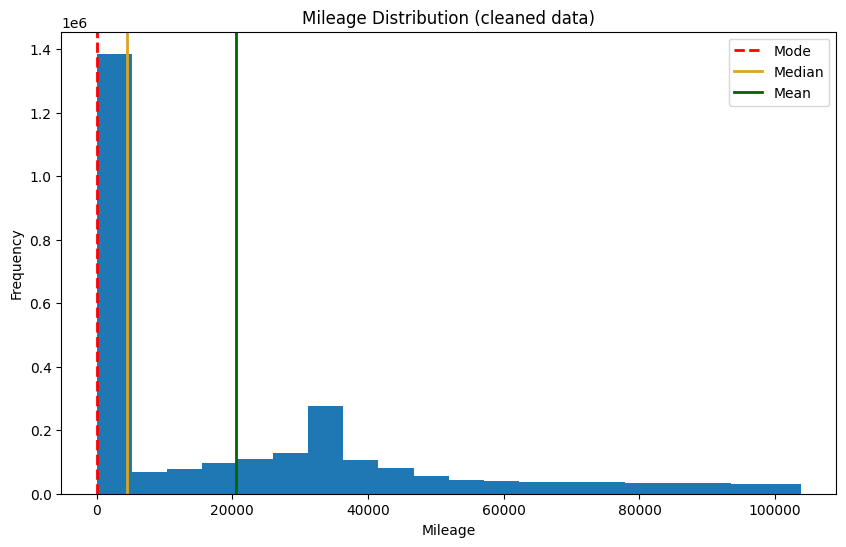

In [23]:
import matplotlib.pyplot as plt
import numpy as np

mileage = new_df["mileage"].to_numpy()

plt.figure(figsize=(10, 6))
plt.hist(mileage, bins=20)
plt.title("Mileage Distribution (cleaned data)")
plt.xlabel("Mileage")
plt.ylabel("Frequency")

# Statistics
mode_val = new_df["mileage"].mode()[0]
median_val = new_df["mileage"].median()
mean_val = new_df["mileage"].mean()

plt.axvline(mode_val, color="r", linestyle="dashed", linewidth=2, label="Mode")
plt.axvline(median_val, color="goldenrod", linewidth=2, label="Median")
plt.axvline(mean_val, color="darkgreen", linewidth=2, label="Mean")

plt.ticklabel_format(style="plain", axis="x")  # no scientific notation on x-axis
plt.legend()
plt.show()


Most cars have very low mileage, which creates a sharp peak near zero. The mean is much higher because a smaller group of cars has very high mileage. Overall, the distribution is right-skewed with many low mileage cars and a long tail of high mileage vehicles.

### Helper: distribution plot for numeric columns

Here we:

* Define a reusable function to plot any numeric column from a Polars DataFrame
* Display mean, median, and mode on the histogram


In [24]:
def plot_distribution(df: pl.DataFrame, column: str, bins: int = 20, title: str = None):
    """
    Plot the distribution of a numeric column in a Polars DataFrame.
    
    Parameters:
        df (pl.DataFrame): Polars DataFrame
        column (str): Column name to plot
        bins (int): Number of histogram bins
        title (str): Optional plot title
    """
    data = df[column].drop_nulls().to_list()
    
    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=bins, edgecolor="black")
    
    # Statistics
    mean_val = np.mean(data)
    median_val = np.median(data)
    mode_series = df[column].drop_nulls().mode()
    mode_val = mode_series[0] if len(mode_series) > 0 else None
    
    plt.axvline(mean_val, color="darkgreen", linestyle="solid", linewidth=2, label="Mean")
    plt.axvline(median_val, color="goldenrod", linestyle="dashed", linewidth=2, label="Median")
    if mode_val is not None:
        plt.axvline(mode_val, color="red", linestyle="dashed", linewidth=2, label="Mode")
    
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(title or f"Distribution of {column}")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Distribution of combined_fuel_economy

Here we:

* Visualize the distribution of the engineered `combined_fuel_economy` feature


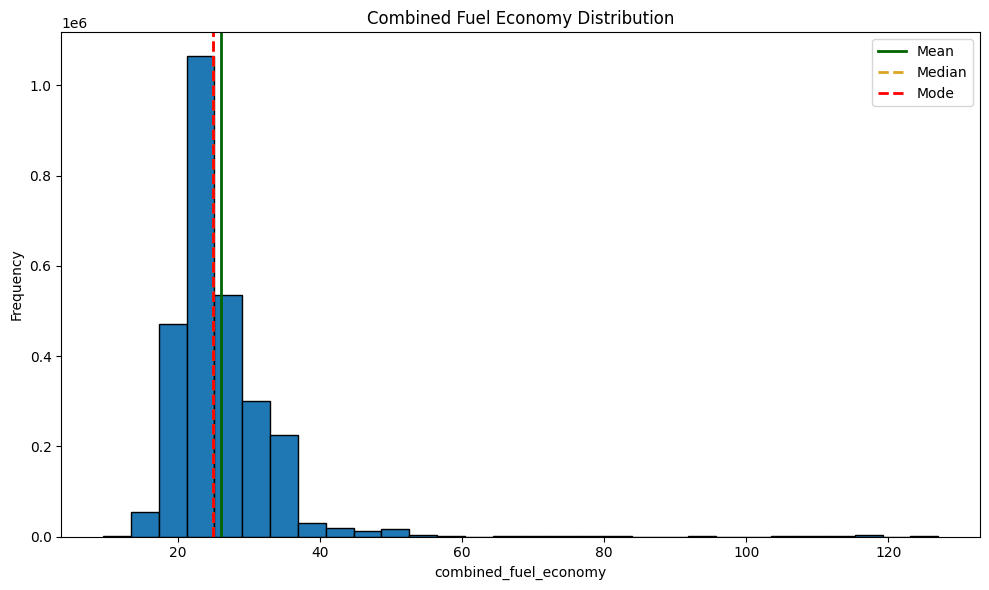

In [25]:
plot_distribution(new_df, column="combined_fuel_economy", bins=30, title="Combined Fuel Economy Distribution")


Most cars have very low mileage, Mode and median are near zero, The mean is higher because a few cars have very high mileage and Distribution is right-skewed.

### Torque distribution

Here we:

* Visualize the distribution of cleaned numeric `torque`


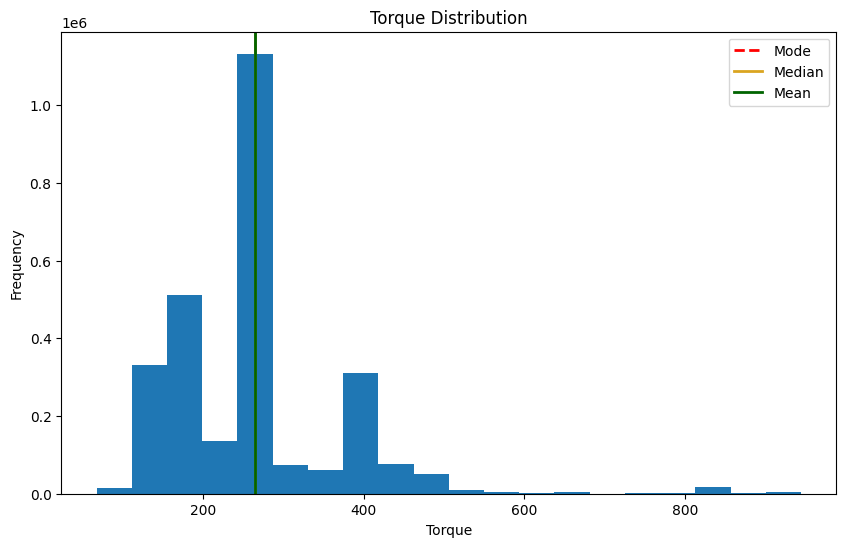

In [26]:
torque_data = new_df["torque"].to_numpy()

plt.figure(figsize=(10, 6))
plt.hist(torque_data, bins=20)
plt.title("Torque Distribution")
plt.xlabel("Torque")
plt.ylabel("Frequency")

mode_val = new_df["torque"].mode()[0]
median_val = new_df["torque"].median()
mean_val = new_df["torque"].mean()

plt.axvline(mode_val, color="r", linestyle="dashed", linewidth=2, label="Mode")
plt.axvline(median_val, color="goldenrod", linewidth=2, label="Median")
plt.axvline(mean_val, color="darkgreen", linewidth=2, label="Mean")

plt.legend()
plt.show()


Most vehicles cluster around 200–250 lb-ft, and the mean is pulled up by a few very high-torque cars. So filling missing torque values with the mean is reasonable for this dataset.

### Size_of_vehicle distribution

Here we:

* Visualize the distribution of the engineered `size_of_vehicle` feature


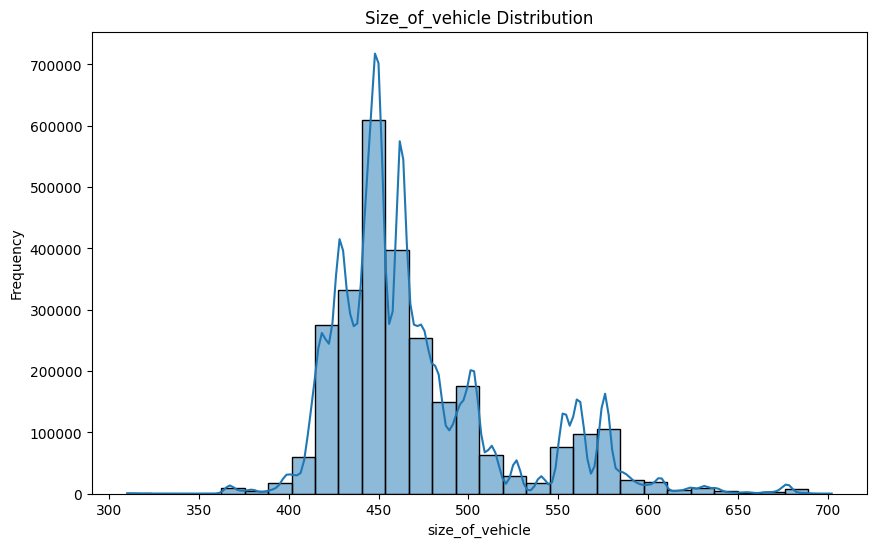

The mean of the size_of_vehicle column is 470.9246663483652.
The median of the size_of_vehicle column is 457.90000000000003.


In [27]:
import warnings
import seaborn as sns

warnings.filterwarnings(
    "ignore",
    message=".*use_inf_as_na option is deprecated.*",
    category=FutureWarning
)

size_data = new_df["size_of_vehicle"].to_numpy()

plt.figure(figsize=(10, 6))
sns.histplot(size_data, bins=30, kde=True)
plt.title("Size_of_vehicle Distribution")
plt.xlabel("size_of_vehicle")
plt.ylabel("Frequency")
plt.show()

print(f"The mean of the size_of_vehicle column is {new_df['size_of_vehicle'].mean()}.")
print(f"The median of the size_of_vehicle column is {new_df['size_of_vehicle'].median()}.")


Most vehicles fall between 430–500. The mean (around 471) is slightly higher than the median (around 458), meaning the distribution is a bit right-skewed. The tail contains a few very large vehicles, which pull the mean upward.

### Price distribution (raw)

Here we:

* Visualize the original `price` distribution in `new_df`


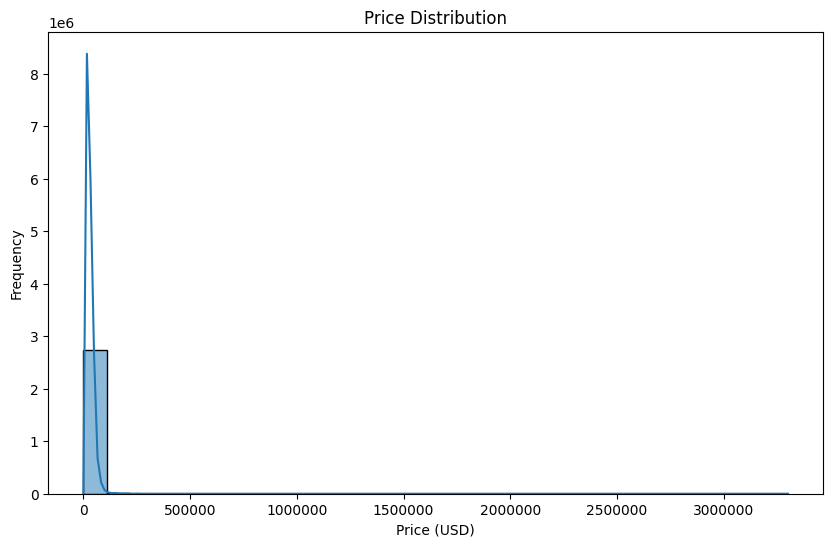

In [28]:
price_data = new_df["price"].to_numpy()

plt.figure(figsize=(10, 6))
sns.histplot(price_data, bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.ticklabel_format(style="plain", axis="x")  # remove scientific notation on x-axis
plt.show()


The graph shows that our target variable is right skewed. This means that the majority of the values are clustered on the left side of the graph. This is not ideal for our model because it will be biased towards the lower values. We will need to transform the target variable to make it more normal.

### Log-transform price feature

Here we:

* Apply a log-transform to the `price` column in `new_df` to reduce skewness
* Visualize the transformed distribution


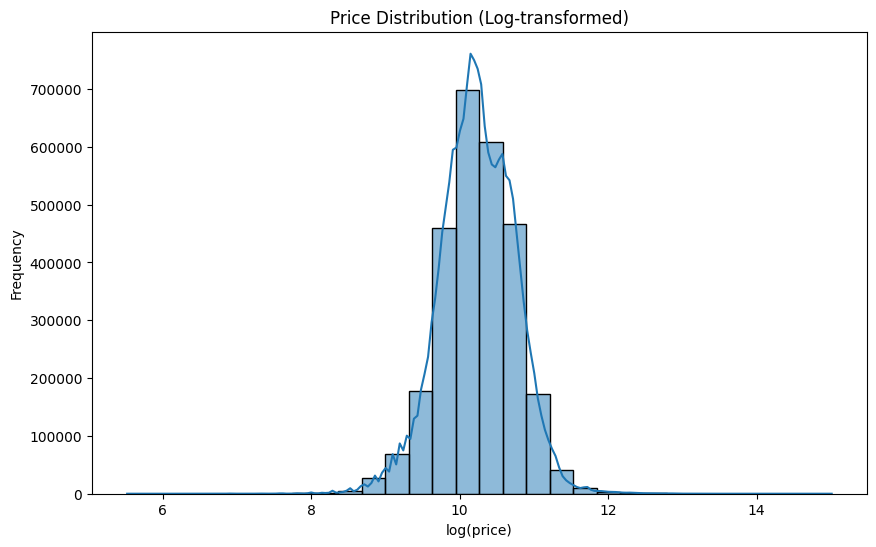

In [29]:
# Create a new column 'price_log' (avoid log(0) by adding a tiny epsilon)
epsilon = 1e-6
new_df = new_df.with_columns(
    (pl.col("price") + epsilon).log().alias("price_log")
)

# Convert to numpy for plotting
price_log = new_df["price_log"].to_numpy()

plt.figure(figsize=(10, 6))
sns.histplot(price_log, bins=30, kde=True)
plt.title("Price Distribution (Log-transformed)")
plt.xlabel("log(price)")
plt.ylabel("Frequency")
plt.ticklabel_format(style="plain", axis="x")
plt.show()


It looks like the majority of vehicles have a mileage of 0 miles before visualization. This is because the vehicles are new. So in this case, we can fill in the null values with the mean value of the column.

### Save new data set

In [30]:
new_df.write_csv("new_dataset.csv")
print("Saved cleaned dataset as 'new_dataset.csv'")


Saved cleaned dataset as 'new_dataset.csv'


### Load New Dataset

In [31]:
import polars as pl

new_df = pl.read_csv("new_dataset.csv")

print("First 5 rows of new_df:")
new_df.head()

First 5 rows of new_df:


price,year,combined_fuel_economy,mileage,fuel_type,transmission,body_type,engine_type,horsepower,torque,legroom,maximum_seating,size_of_vehicle,has_incidents,wheel_system,major_options_count,description,price_log
f64,i64,f64,f64,str,str,str,str,f64,f64,f64,i64,f64,bool,str,f64,str,f64
25980.0,2020,27.0,3070.0,"""Gasoline""","""A""","""SUV / Crossover""","""I4""",187.0,186.0,80.6,5,450.0,false,"""AWD""",6.0,"""2020 Mazda CX-5 Touring Certif…",10.165082
8349.0,2013,28.0,95540.0,"""Gasoline""","""A""","""SUV / Crossover""","""I4""",240.0,270.0,77.2,5,447.2,false,"""FWD""",1.0,"""Visit The Auto Store online at…",9.029897
14936.0,2019,33.0,33457.0,"""Gasoline""","""CVT""","""Sedan""","""I4""",124.0,125.0,79.9,5,429.8,false,"""FWD""",3.0,"""This 2019 Nissan Sentra SV in …",9.61153
25935.0,2020,26.5,8.0,"""Gasoline""","""CVT""","""SUV / Crossover""","""I4""",152.0,265.218839,76.2,5,431.9,false,"""AWD""",2.0,"""Mitsubishi has found new life …",10.163349
47235.0,2020,18.0,10.0,"""Gasoline""","""A""","""Pickup Truck""","""V8""",395.0,410.0,86.1,5,563.2,false,"""4WD""",10.0,"""Bright White Clearcoat 2020 Ra…",10.76289


### Inspect shape and schema of new_df

In [32]:
print("Dataset shape (rows, columns):", new_df.shape)

print("\nColumns:")
print(new_df.columns)

print("\nDtypes (schema):")
print(new_df.schema)


Dataset shape (rows, columns): (2743730, 18)

Columns:
['price', 'year', 'combined_fuel_economy', 'mileage', 'fuel_type', 'transmission', 'body_type', 'engine_type', 'horsepower', 'torque', 'legroom', 'maximum_seating', 'size_of_vehicle', 'has_incidents', 'wheel_system', 'major_options_count', 'description', 'price_log']

Dtypes (schema):
Schema([('price', Float64), ('year', Int64), ('combined_fuel_economy', Float64), ('mileage', Float64), ('fuel_type', String), ('transmission', String), ('body_type', String), ('engine_type', String), ('horsepower', Float64), ('torque', Float64), ('legroom', Float64), ('maximum_seating', Int64), ('size_of_vehicle', Float64), ('has_incidents', Boolean), ('wheel_system', String), ('major_options_count', Float64), ('description', String), ('price_log', Float64)])


### Basic statistics of numeric columns


In [33]:
print("Statistics summary for numeric columns:")
new_df.describe()


Statistics summary for numeric columns:


statistic,price,year,combined_fuel_economy,mileage,fuel_type,transmission,body_type,engine_type,horsepower,torque,legroom,maximum_seating,size_of_vehicle,has_incidents,wheel_system,major_options_count,description,price_log
str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,str,f64
"""count""",2.74373e6,2.74373e6,2.74373e6,2.74373e6,"""2743730""","""2743730""","""2743730""","""2743730""",2.74373e6,2.74373e6,2.74373e6,2.74373e6,2.74373e6,2.74373e6,"""2743730""",2.74373e6,"""2674103""",2.74373e6
"""null_count""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,"""69627""",0.0
"""mean""",31732.499246,2018.453363,26.162156,20549.444585,null,null,null,null,243.734961,264.886511,80.268631,5.438959,470.924666,0.0,null,6.34677,null,10.237845
"""std""",19335.293634,3.345399,7.611714,26682.770796,null,null,null,null,90.720814,108.234612,3.320223,1.138906,48.944922,null,null,3.447025,null,0.503982
"""min""",250.0,1915.0,9.5,0.0,"""Biodiesel""","""A""","""Convertible""","""Diesel engine""",63.0,68.0,0.0,2.0,310.2,0.0,"""4WD""",1.0,""" At Florida AutoSport we…",5.521461
"""25%""",20148.0,2017.0,22.5,5.0,null,null,null,null,170.0,181.0,78.3,5.0,440.3,null,null,4.0,null,9.91086
"""50%""",27885.0,2020.0,25.0,4432.0,null,null,null,null,228.0,265.218839,80.166305,5.0,457.9,null,null,6.0,null,10.235844
"""75%""",39580.0,2020.0,28.5,32991.0,null,null,null,null,300.0,275.0,81.7,6.0,486.4,null,null,8.0,null,10.586079
"""max""",3.299995e6,2021.0,127.0,103813.0,"""Propane""","""M""","""Wagon""","""W8""",1001.0,944.0,104.963605,15.0,702.0,0.0,"""RWD""",59.0,"""�� Runs and drives gre…",15.009432


### Basic statistics for categorical columns


In [34]:
import numpy as np

print("Statistics summary for categorical columns:")

cat_cols = [col for col, dtype in new_df.schema.items()
            if dtype == pl.Utf8 or dtype == pl.Categorical]

summary_list = []

for col in cat_cols:
    series = new_df[col]
    count = series.drop_nulls().len()
    unique = series.n_unique()
    mode_series = series.drop_nulls().mode()
    top = mode_series[0] if len(mode_series) > 0 else None
    freq = new_df.filter(pl.col(col) == top).height if top is not None else 0

    summary_list.append({
        "column": col,
        "count": count,
        "unique": unique,
        "top": top,
        "freq": freq
    })

cat_summary = pl.DataFrame(summary_list)
print(cat_summary)


Statistics summary for categorical columns:
shape: (6, 5)
┌──────────────┬─────────┬─────────┬─────────────────────────────────┬─────────┐
│ column       ┆ count   ┆ unique  ┆ top                             ┆ freq    │
│ ---          ┆ ---     ┆ ---     ┆ ---                             ┆ ---     │
│ str          ┆ i64     ┆ i64     ┆ str                             ┆ i64     │
╞══════════════╪═════════╪═════════╪═════════════════════════════════╪═════════╡
│ fuel_type    ┆ 2743730 ┆ 7       ┆ Gasoline                        ┆ 2487857 │
│ transmission ┆ 2743730 ┆ 4       ┆ A                               ┆ 2250369 │
│ body_type    ┆ 2743730 ┆ 9       ┆ SUV / Crossover                 ┆ 1332316 │
│ engine_type  ┆ 2743730 ┆ 40      ┆ I4                              ┆ 1343577 │
│ wheel_system ┆ 2743730 ┆ 5       ┆ FWD                             ┆ 1291714 │
│ description  ┆ 2674103 ┆ 2289784 ┆ [!@@Additional Info@@!]Front W… ┆ 1064    │
└──────────────┴─────────┴─────────┴───────────────

### Duplicates, missing, unique counts

In [35]:
# Duplicate rows
total_rows = new_df.height
unique_rows = new_df.unique().height
num_duplicates = total_rows - unique_rows

print("Number of duplicate rows:", num_duplicates)

# Missing values per column
print("\nMissing values per column:")
missing_values = new_df.null_count()
print(missing_values)

# Missing percentage per column
print("\nMissing value percentage per column:")
missing_percent = (new_df.null_count() / new_df.height * 100)
print(missing_percent)

# Number of unique values per column
print("\nNumber of unique values per column:")
unique_values = new_df.select([pl.col(col).n_unique().alias(col) for col in new_df.columns])
print(unique_values)


Number of duplicate rows: 150289

Missing values per column:
shape: (1, 18)
┌───────┬──────┬──────────────┬─────────┬───┬──────────────┬─────────────┬─────────────┬───────────┐
│ price ┆ year ┆ combined_fue ┆ mileage ┆ … ┆ wheel_system ┆ major_optio ┆ description ┆ price_log │
│ ---   ┆ ---  ┆ l_economy    ┆ ---     ┆   ┆ ---          ┆ ns_count    ┆ ---         ┆ ---       │
│ u32   ┆ u32  ┆ ---          ┆ u32     ┆   ┆ u32          ┆ ---         ┆ u32         ┆ u32       │
│       ┆      ┆ u32          ┆         ┆   ┆              ┆ u32         ┆             ┆           │
╞═══════╪══════╪══════════════╪═════════╪═══╪══════════════╪═════════════╪═════════════╪═══════════╡
│ 0     ┆ 0    ┆ 0            ┆ 0       ┆ … ┆ 0            ┆ 0           ┆ 69627       ┆ 0         │
└───────┴──────┴──────────────┴─────────┴───┴──────────────┴─────────────┴─────────────┴───────────┘

Missing value percentage per column:
shape: (1, 18)
┌───────┬──────┬──────────────┬─────────┬───┬──────────────┬───

### Correlation heatmap and numeric histograms


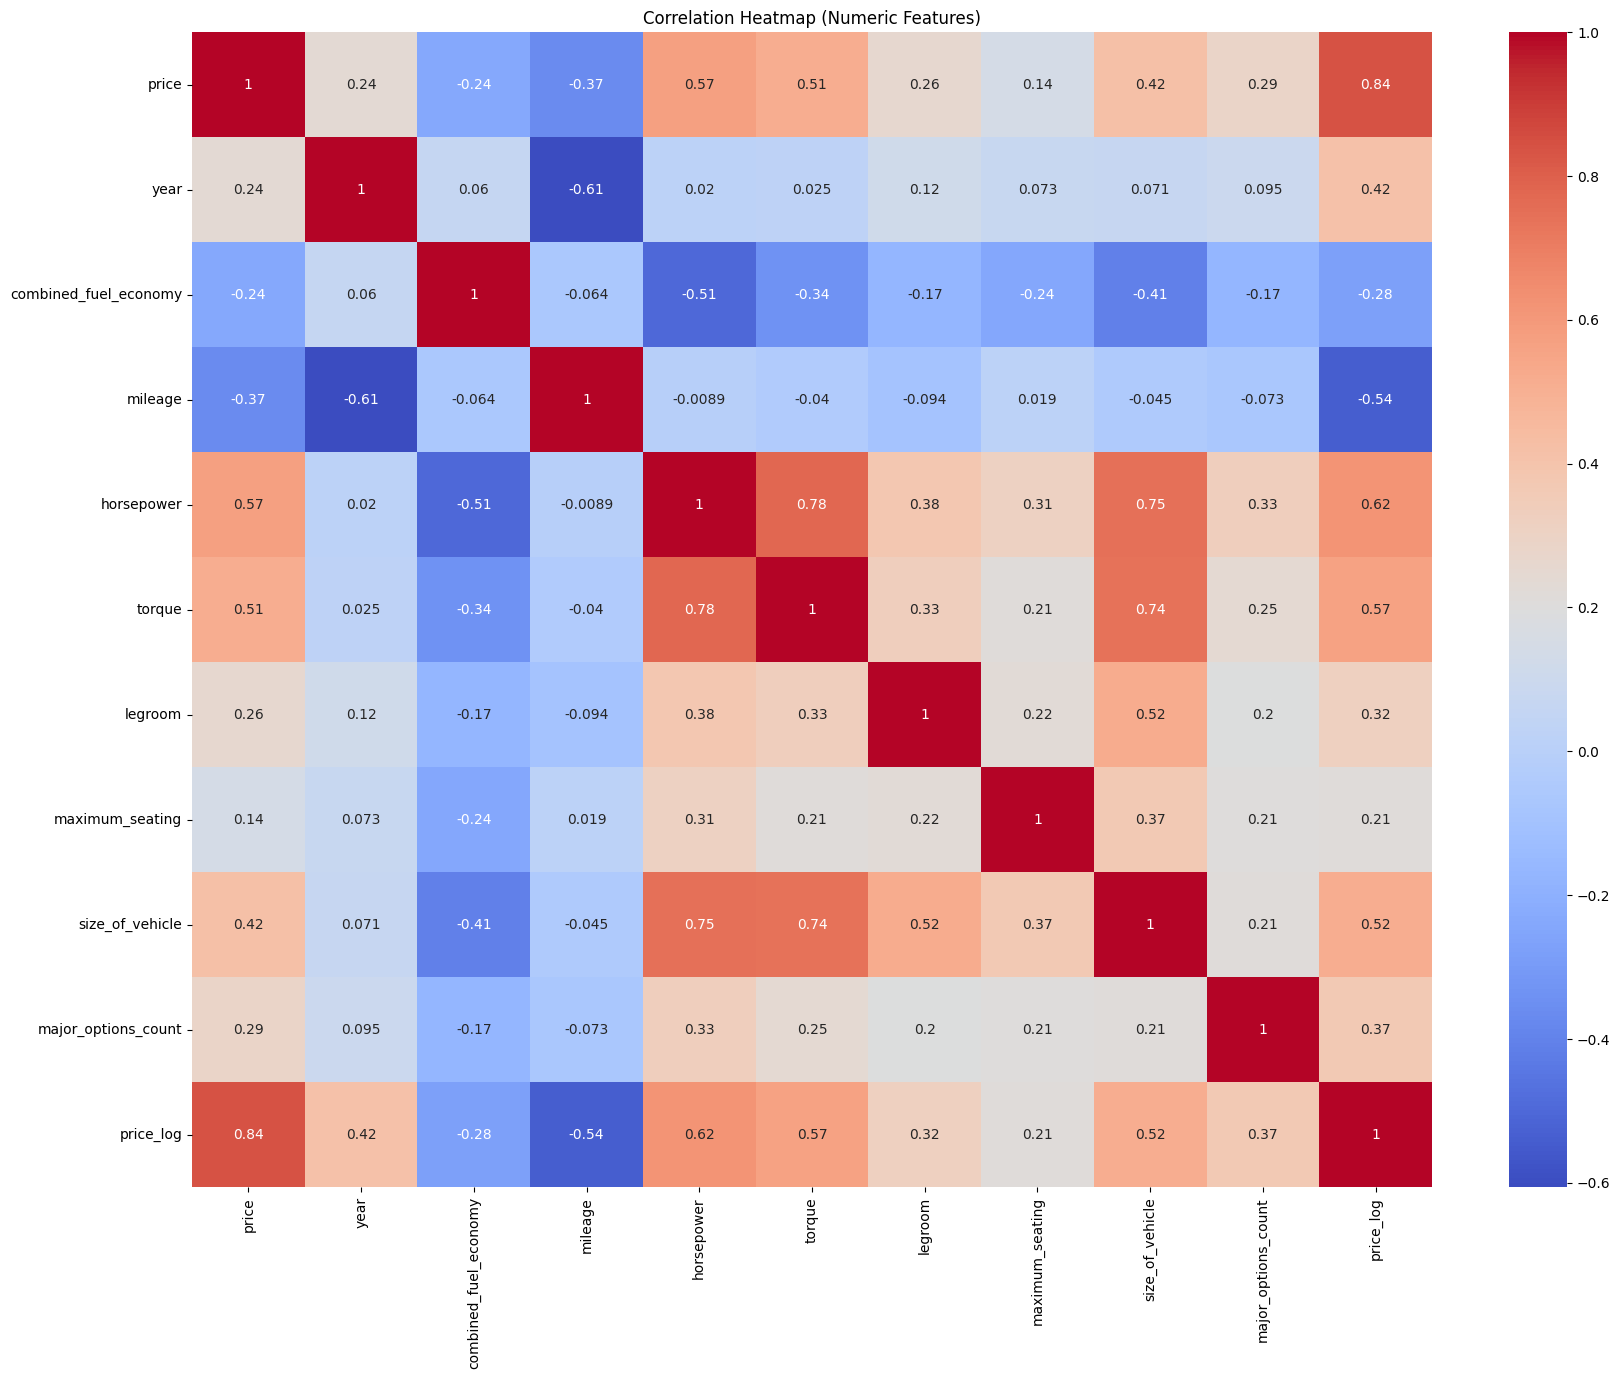

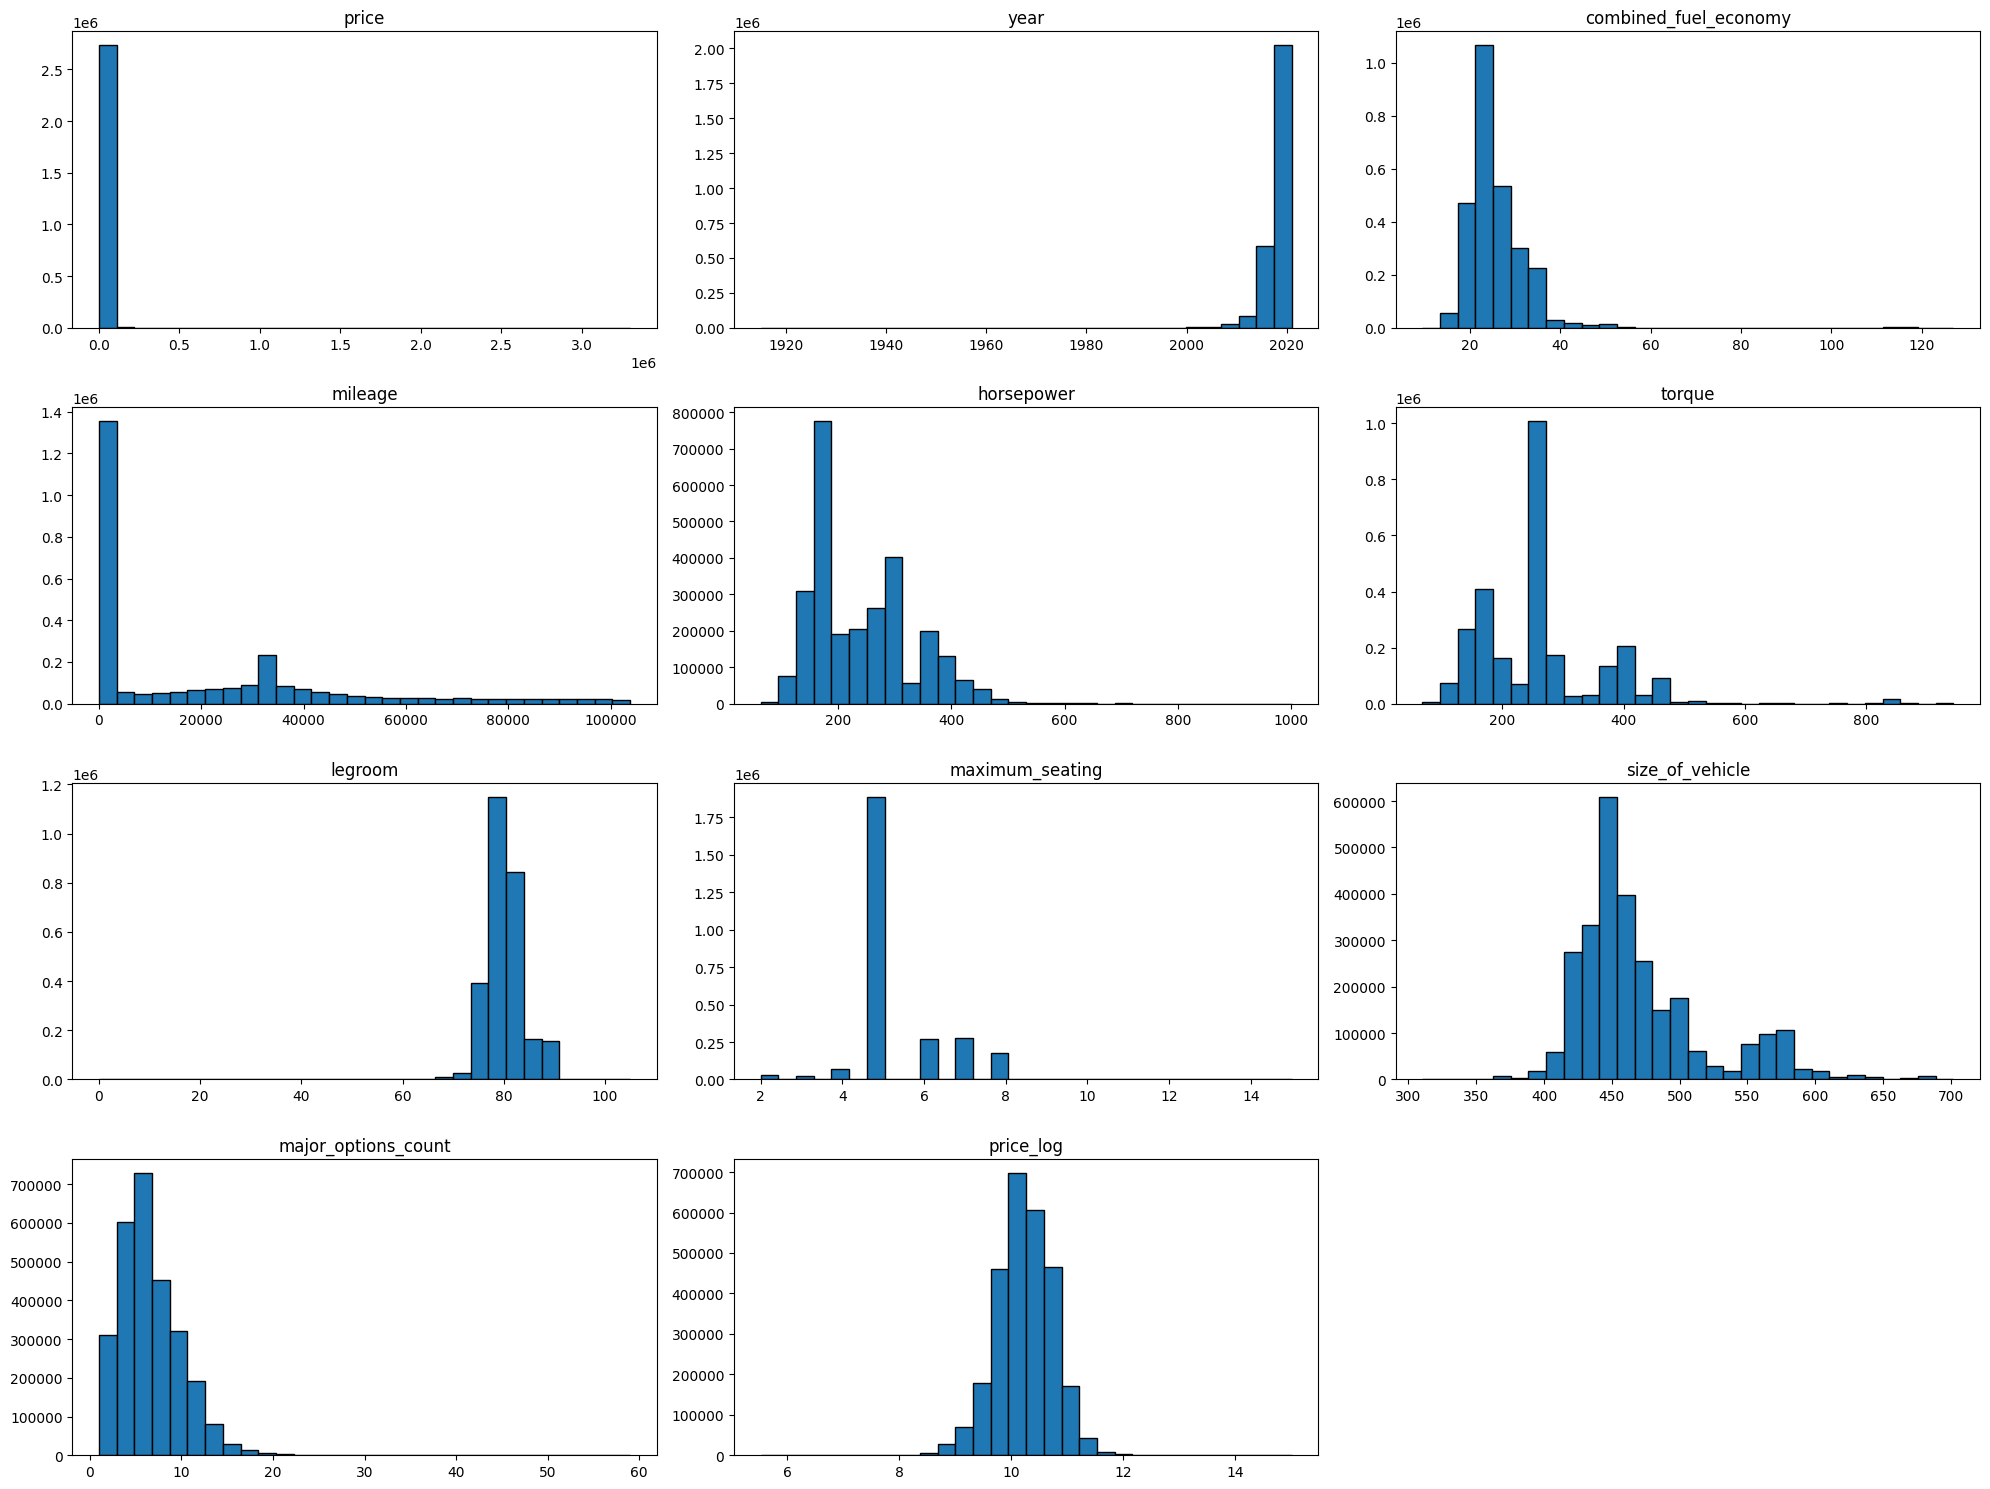

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Select numeric columns from new_df (without NUMERIC_DTYPES)
numeric_types = (
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
)

numeric_cols = [col for col, dtype in new_df.schema.items() if dtype in numeric_types]
numeric_df = new_df.select(numeric_cols)

# Build pandas DataFrame manually (avoids pyarrow)
numeric_pd = pd.DataFrame({
    col: numeric_df[col].to_numpy()
    for col in numeric_cols
})

# Correlation matrix
corr_matrix = numeric_pd.corr()

corr_matrix = corr_matrix.replace([np.inf, -np.inf], np.nan).fillna(0)

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# Histograms for each numeric column
plt.figure(figsize=(20, 15))
n_cols = len(numeric_cols)
n_rows = int(np.ceil(n_cols / 3))  # 3 plots per row

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 3, i)
    plt.hist(numeric_pd[col], bins=30, edgecolor="black")
    plt.title(col)

plt.tight_layout()
plt.show()


Price is strongly correlated with horsepower, torque, and vehicle size, meaning bigger and more powerful cars cost more.
Mileage has a clear negative correlation with price, so cars with higher mileage are cheaper.
Horsepower, torque, and size are also strongly correlated with each other, which makes sense since larger engines produce more power.
Other correlations are weak and do not meaningfully affect the model.

Most numeric features are right-skewed. Price, mileage, horsepower, and torque all have long right tails caused by a small number of very expensive or high-performance cars. Year is concentrated around newer models, and combined fuel economy forms a tight peak around 20–30 MPG.
Maximum seating has clear clusters (5, 7, and 8 seats). Size_of_vehicle and legroom show compact, centred distributions with small tails.

### Pairwise relationships: price vs year, horsepower vs torque


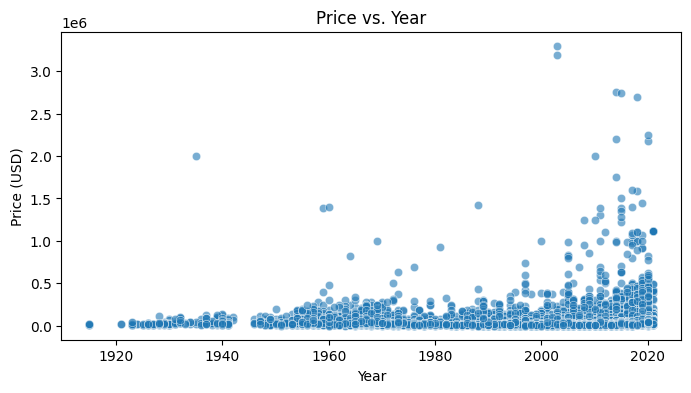

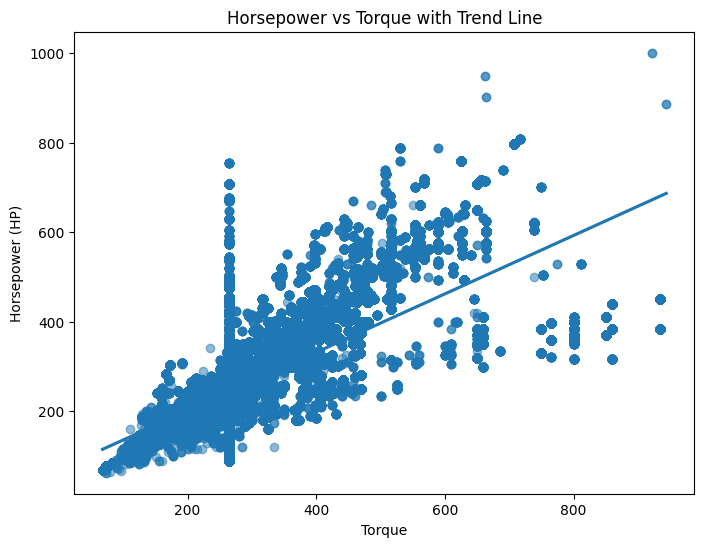

In [37]:
# Price vs Year
plt.figure(figsize=(8, 4))
sns.scatterplot(
    x=new_df["year"].to_list(),
    y=new_df["price"].to_list(),
    alpha=0.6
)
plt.title("Price vs. Year")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.show()

# Horsepower vs Torque with trend line
df_clean = new_df.select([
    pl.col("torque").cast(pl.Float64),
    pl.col("horsepower").cast(pl.Float64)
]).drop_nulls()

plt.figure(figsize=(8, 6))
sns.regplot(
    x=df_clean["torque"].to_list(),
    y=df_clean["horsepower"].to_list(),
    scatter_kws={"alpha": 0.5}
)
plt.title("Horsepower vs Torque with Trend Line")
plt.xlabel("Torque")
plt.ylabel("Horsepower (HP)")
plt.show()


Newer cars are generally more expensive, and the price spread increases sharply after 2000.
Older cars stay in a low price range, while modern cars include many high-end and luxury models, creating the tall upper spread.
Overall, price tends to rise with year, but with large variation for newer vehicles.

Horsepower increases as torque increases, and the trend line confirms a strong positive relationship. Most cars cluster between 150–500 HP and 150–500 lb-ft, with high-performance cars extending far above that range.
Overall, torque is a good indicator of engine power.

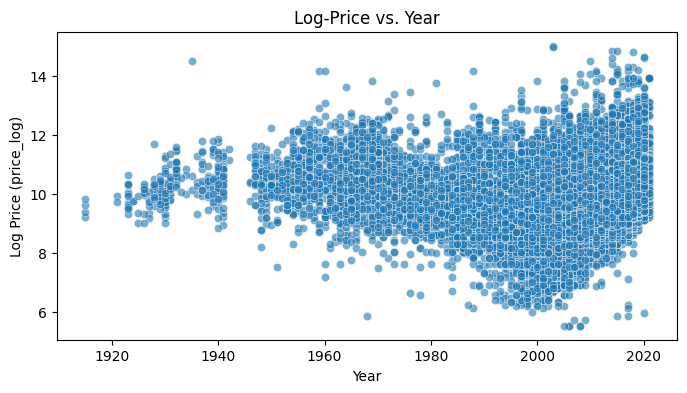

In [38]:
# Price_log vs Year

plt.figure(figsize=(8, 4))
sns.scatterplot(
    x=new_df["year"].to_list(),
    y=new_df["price_log"].to_list(),   # use log price
    alpha=0.6
)
plt.title("Log-Price vs. Year")
plt.xlabel("Year")
plt.ylabel("Log Price (price_log)")
plt.show()


### Label encoding of categorical/boolean features

Here we:

* Encode all categorical and boolean columns in `new_df` as integer codes
* Keep numeric columns unchanged
* Store mapping dictionaries for interpretability


In [39]:
encoded_df = new_df.clone()
label_mapping_dict = {}

# Columns to encode: Utf8, Categorical, Boolean
cols_to_encode = [
    col for col, dtype in zip(encoded_df.columns, encoded_df.dtypes)
    if dtype in (pl.Utf8, pl.Categorical, pl.Boolean) 
    and col != "description"  
]

print("Columns to label-encode:")
print(cols_to_encode)

for col in cols_to_encode:
    # Build mapping from original values to integer codes
    unique_vals = new_df[col].unique().to_list()
    mapping = {val: i for i, val in enumerate(unique_vals)}

    # Apply mapping and CAST TO INTEGER
    encoded_df = encoded_df.with_columns(
        pl.col(col)
        .replace(mapping)
        .cast(pl.Int64)          
        .alias(col)
    )

    # Store mapping with string keys for JSON
    label_mapping_dict[col] = {str(k): int(v) for k, v in mapping.items()}

    # Optional: print mapping
    print(f"\nMapping for column '{col}':")
    for k, v in label_mapping_dict[col].items():
        print(f"  {k} → {v}")


Columns to label-encode:
['fuel_type', 'transmission', 'body_type', 'engine_type', 'has_incidents', 'wheel_system']

Mapping for column 'fuel_type':
  Flex Fuel Vehicle → 0
  Diesel → 1
  Biodiesel → 2
  Propane → 3
  Gasoline → 4
  Hybrid → 5
  Compressed Natural Gas → 6

Mapping for column 'transmission':
  A → 0
  M → 1
  Dual Clutch → 2
  CVT → 3

Mapping for column 'body_type':
  Minivan → 0
  Wagon → 1
  Pickup Truck → 2
  Sedan → 3
  SUV / Crossover → 4
  Convertible → 5
  Hatchback → 6
  Coupe → 7
  Van → 8

Mapping for column 'engine_type':
  I4 Diesel → 0
  I3 → 1
  H4 → 2
  Gasoline engine → 3
  V6 Compressed Natural Gas → 4
  W12 Flex Fuel Vehicle → 5
  H6 → 6
  V8 Biodiesel → 7
  V8 Flex Fuel Vehicle → 8
  V8 Compressed Natural Gas → 9
  I4 → 10
  V10 → 11
  I4 Hybrid → 12
  V6 → 13
  V12 → 14
  I5 Biodiesel → 15
  R2 → 16
  Diesel engine → 17
  V8 Propane → 18
  H4 Hybrid → 19
  I6 Hybrid → 20
  I4 Compressed Natural Gas → 21
  I2 → 22
  I3 Hybrid → 23
  V12 Hybrid → 24
 

### Save label mappings and encoded dataset


We temporarily save this label and value mapping dataset to json , it will be useful after final feature selection, and deploying to web requires understanding what is the corresponding value for each categorical label

In [40]:
import json

with open("/kaggle/working/label_mappings.json", "w", encoding="utf-8") as f:
    json.dump(label_mapping_dict, f, ensure_ascii=False, indent=4)

print("Saved label mappings to 'label_mappings.json'")


Saved label mappings to 'label_mappings.json'


### Preview of encoded dataset and mappings


In [41]:
print("Encoded dataset (first 5 rows):")
encoded_df.head()

print("\nColumns in encoded_df:")
print(encoded_df.columns)

print("\nExample mapping dictionaries:")
for i, (col, mapping) in enumerate(label_mapping_dict.items()):
    print(f"\nColumn: {col}")
    for k, v in list(mapping.items())[:5]:  # show first 5 entries
        print(f"  {k} → {v}")
    if i >= 2:  # show mappings for at most 3 columns
        break


Encoded dataset (first 5 rows):

Columns in encoded_df:
['price', 'year', 'combined_fuel_economy', 'mileage', 'fuel_type', 'transmission', 'body_type', 'engine_type', 'horsepower', 'torque', 'legroom', 'maximum_seating', 'size_of_vehicle', 'has_incidents', 'wheel_system', 'major_options_count', 'description', 'price_log']

Example mapping dictionaries:

Column: fuel_type
  Flex Fuel Vehicle → 0
  Diesel → 1
  Biodiesel → 2
  Propane → 3
  Gasoline → 4

Column: transmission
  A → 0
  M → 1
  Dual Clutch → 2
  CVT → 3

Column: body_type
  Minivan → 0
  Wagon → 1
  Pickup Truck → 2
  Sedan → 3
  SUV / Crossover → 4


### Correlation of numeric features with price

Here we:

* Keep only numeric columns
* Drop columns with too many missing values
* Optionally drop near-constant (low variance) columns
* Compute Pearson correlation of each numeric feature with `price`
* Visualize correlations as a bar chart


Correlation with price:
price_log: 0.8428
horsepower: 0.5731
torque: 0.5113
size_of_vehicle: 0.4177
mileage: -0.3670
major_options_count: 0.2886
legroom: 0.2587
combined_fuel_economy: -0.2391
year: 0.2362
maximum_seating: 0.1420


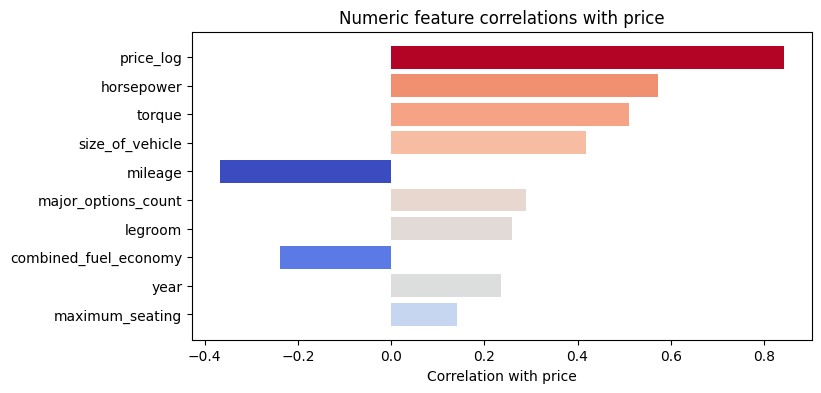

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Keep only numeric columns (all common numeric Polars types)
numeric_types = (
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
)

numeric_cols = [col for col, dtype in new_df.schema.items() if dtype in numeric_types]
numeric_df = new_df.select(numeric_cols)

# Step 2: Drop columns with too many missing values (keep >= 90% non-null)
threshold = 0.9 * numeric_df.height
valid_cols = [col for col in numeric_df.columns if numeric_df[col].drop_nulls().len() >= threshold]
numeric_df = numeric_df.select(valid_cols)

# Step 3: Optional variance threshold filter (remove very low-variance columns)
variance_dict = {}
for col in numeric_df.columns:
    arr = numeric_df[col].to_numpy()
    variance = np.var(arr)
    variance_dict[col] = variance

# Keep columns with variance > 0.01
filtered_cols = [col for col, var in variance_dict.items() if var > 0.01]

# Ensure 'price' is included for correlation
if "price" not in filtered_cols:
    filtered_cols.append("price")

numeric_df = new_df.select(filtered_cols)

# Step 4: Compute correlation with price
corr_dict = {}
for col in numeric_df.columns:
    if col != "price":
        corr_value = numeric_df.select(
            pl.corr(pl.col(col), pl.col("price")).alias("corr")
        ).to_numpy()[0][0]
        corr_dict[col] = corr_value

# Sort correlations by absolute value (strongest first)
sorted_corr = dict(sorted(corr_dict.items(), key=lambda x: abs(x[1]), reverse=True))

print("Correlation with price:")
for col, val in sorted_corr.items():
    print(f"{col}: {val:.4f}")

# Step 5: Visualize as horizontal bar chart
cols = list(sorted_corr.keys())
vals = np.array(list(sorted_corr.values()))

plt.figure(figsize=(8, len(cols) * 0.4))

if len(vals) > 0 and np.max(vals) != np.min(vals):
    norm_vals = (vals - np.min(vals)) / (np.max(vals) - np.min(vals))
else:
    norm_vals = np.zeros_like(vals)

plt.barh(cols, vals, color=plt.cm.coolwarm(norm_vals))
plt.xlabel("Correlation with price")
plt.title("Numeric feature correlations with price")
plt.gca().invert_yaxis()
plt.show()


Horsepower, torque, and vehicle size show the strongest positive correlations with price, meaning powerful and larger cars are usually more expensive.
Mileage has the strongest negative correlation, so high-mileage cars tend to be cheaper.
Fuel economy also has a mild negative correlation, as efficient cars are often smaller and less powerful.
Other features (year, seating, daysonmarket) have only weak influence on price

### Save Encoded Dataset

In [43]:
encoded_df = encoded_df.drop("description")
encoded_df.write_csv("encoded_dataset.csv")
print("Saved cleaned dataset as 'encoded_dataset.csv'")


Saved cleaned dataset as 'encoded_dataset.csv'


### Final sanity checks for Phase 3


In [44]:
print("=== SHAPES ===")
try:
    print(f"Original df shape:        {df.shape}")
except NameError:
    print("Original df not in memory anymore.")
print(f"Cleaned new_df shape:     {new_df.shape}")
try:
    print(f"Encoded encoded_df shape: {encoded_df.shape}")
except NameError:
    print("encoded_df not defined (skip encoding checks).")

# 1. Check that key columns exist in new_df
required_cols = [
    "price", "daysonmarket",
    "year", "combined_fuel_economy", "mileage",
    "fuel_type", "transmission", "body_type", "engine_type",
    "horsepower", "torque", "legroom", "maximum_seating",
    "size_of_vehicle", "has_incidents", "wheel_system",
    "make_name", "is_new",
]

missing_cols = [c for c in required_cols if c not in new_df.columns]
extra_cols   = [
    c for c in new_df.columns
    if c not in required_cols and c not in ["price_log"]
]

print("\n=== COLUMN CHECKS ===")
print("Missing required columns in new_df:", missing_cols)
print("Extra columns in new_df (besides price_log):", extra_cols)

# 2. Check missing values in key columns
print("\n=== MISSING VALUES IN KEY COLUMNS (new_df) ===")
missing_report = {}
for col in required_cols:
    if col in new_df.columns:
        n_null = int(new_df[col].null_count())
        missing_report[col] = n_null
        print(f"{col}: {n_null} nulls")

# 3. Quick overall null-count check
null_counts_df = new_df.null_count()      # 1-row DataFrame
total_nulls = int(sum(null_counts_df.row(0)))

print(f"\nTotal nulls in new_df: {total_nulls}")

# 4. encoded_df checks (if available)
try:
    print("\n=== ENCODED_DF CHECKS ===")
    # same number of rows?
    if encoded_df.height == new_df.height:
        print("Row count matches between new_df and encoded_df")
    else:
        print(f"Row count mismatch: new_df={new_df.height}, encoded_df={encoded_df.height}")

    # Check that encoded_df has only numeric columns
    non_numeric_cols = [
        col for col, dtype in encoded_df.schema.items()
        if dtype not in (
            pl.Int8, pl.Int16, pl.Int32, pl.Int64,
            pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
            pl.Float32, pl.Float64
        )
    ]
    if len(non_numeric_cols) == 0:
        print("All columns in encoded_df are numeric")
    else:
        print("Non-numeric columns in encoded_df:", non_numeric_cols)
except NameError:
    pass

print("\n=== SAMPLE ROWS FROM new_df ===")
print(new_df.head())

print("\nFinal sanity check complete")


=== SHAPES ===
Original df shape:        (2743730, 59)
Cleaned new_df shape:     (2743730, 18)
Encoded encoded_df shape: (2743730, 17)

=== COLUMN CHECKS ===
Missing required columns in new_df: ['daysonmarket', 'make_name', 'is_new']
Extra columns in new_df (besides price_log): ['major_options_count', 'description']

=== MISSING VALUES IN KEY COLUMNS (new_df) ===
price: 0 nulls
year: 0 nulls
combined_fuel_economy: 0 nulls
mileage: 0 nulls
fuel_type: 0 nulls
transmission: 0 nulls
body_type: 0 nulls
engine_type: 0 nulls
horsepower: 0 nulls
torque: 0 nulls
legroom: 0 nulls
maximum_seating: 0 nulls
size_of_vehicle: 0 nulls
has_incidents: 0 nulls
wheel_system: 0 nulls

Total nulls in new_df: 69627

=== ENCODED_DF CHECKS ===
Row count matches between new_df and encoded_df
All columns in encoded_df are numeric

=== SAMPLE ROWS FROM new_df ===
shape: (5, 18)
┌─────────┬──────┬─────────────┬─────────┬───┬─────────────┬─────────────┬─────────────┬───────────┐
│ price   ┆ year ┆ combined_fu ┆ mil

The cleaned dataset is fully consistent.
All required numeric and categorical columns are present, and no missing values remain in the selected features.
Row counts match across all versions, and the encoded dataset is entirely numeric and ready for modelling.